Carga de datos y Eliminación de columnas irrelevantes

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Cargar los datos limpios
df = pd.read_csv("datos_tratados.csv")

# 2. Eliminar columnas irrelevantes (Ej. customerID)
col_id = [col for col in df.columns if 'ID' in col.upper()]
if col_id:
    df = df.drop(columns=col_id)
    print(f"Columna eliminada exitosamente: {col_id}")

# Eliminamos la columna original 'Churn' en texto (Si aún existe),
# ya que en la parte 1 creamos 'Churn_Binario'
col_churn_str = [col for col in df.columns if col.lower() == 'churn']
if col_churn_str:
    df = df.drop(columns=col_churn_str)

print(f"Dimensiones actuales de los datos: {df.shape}")
df.head(3)

Columna eliminada exitosamente: ['customerID']
Dimensiones actuales de los datos: (7267, 21)


,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Churn_Binario,Cuentas_Diarias
0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,0.0,2.186667
1,Male,0,No,No,9,Yes,Yes,DSL,No,No,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,0.0,1.996667
2,Male,0,No,No,4,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,1.0,2.463333


Encoding y Balance de Clases

In [25]:
# 3. Verificar el balance de clases en la variable objetivo
print("--- Proporción de Evasión (Churn_Binario) ---")
print((df['Churn_Binario'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

# 4. Separar las características (X) de lo que queremos predecir (y)
X = df.drop(columns=['Churn_Binario'])
y = df['Churn_Binario']

# 5. Aplicar One-Hot Encoding (Convierte texto en columnas binarias)
X_encoded = pd.get_dummies(X, drop_first=True)
print(f"Columnas numéricas generadas para el modelo: {X_encoded.shape[1]}")

--- Proporción de Evasión (Churn_Binario) ---
Churn_Binario
0.0    74.28%
1.0    25.72%
Name: proportion, dtype: object
Columnas numéricas generadas para el modelo: 31


Balanceo (SMOTE), División de Datos y Normalización

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 6. División de datos (70% Entrenamiento / 30% Prueba)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

# 7. Balanceo con SMOTE (Aplicado SOLO al entrenamiento)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"Balance en entrenamiento tras aplicar SMOTE:\n{y_train_sm.value_counts()}")

# 8. Normalización / Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# Volvemos a ponerle los nombres a las columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_encoded.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_encoded.columns)

Balance en entrenamiento tras aplicar SMOTE:
Churn_Binario
0.0    3778
1.0    3778
Name: count, dtype: int64


Entrenamiento y Evaluación de Modelos

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- MODELO 1: Regresión Logística (Usa datos normalizados) ---
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train_sm)
y_pred_lr = modelo_lr.predict(X_test_scaled)

# --- MODELO 2: Random Forest (Usa datos NO normalizados) ---
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
modelo_rf.fit(X_train_sm, y_train_sm)
y_pred_rf = modelo_rf.predict(X_test)

def evaluar_modelo(nombre, y_true, y_pred):
    print(f"========== {nombre} ==========")
    print(f"Exactitud (Accuracy) : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precisión (Precision): {precision_score(y_true, y_pred):.4f}")
    print(f"Recall (Sensibilidad): {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score             : {f1_score(y_true, y_pred):.4f}")
    print("Matriz de Confusión  :\n", confusion_matrix(y_true, y_pred), "\n")

evaluar_modelo("REGRESIÓN LOGÍSTICA (Con Normalización)", y_test, y_pred_lr)
evaluar_modelo("RANDOM FOREST (Sin Normalización)", y_test, y_pred_rf)

========== REGRESIÓN LOGÍSTICA (Con Normalización) ==========
Exactitud (Accuracy) : 0.7749
Precisión (Precision): 0.5547
Recall (Sensibilidad): 0.6328
F1-Score             : 0.5912
Matriz de Confusión  :
 [[1335  285]
 [ 206  355]] 

========== RANDOM FOREST (Sin Normalización) ==========
Exactitud (Accuracy) : 0.7781
Precisión (Precision): 0.5577
Recall (Sensibilidad): 0.6631
F1-Score             : 0.6059
Matriz de Confusión  :
 [[1325  295]
 [ 189  372]] 



Análisis de Importancia de Variables

/tmp/ipython-input-217/582102748.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancias, x='Importancia', y='Variable', palette='magma')


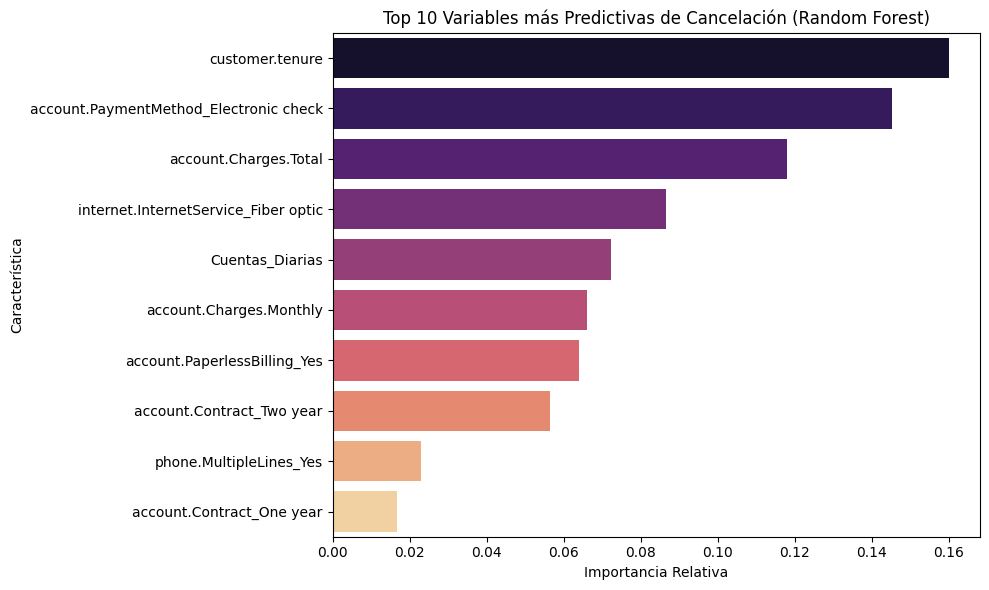

In [28]:
# Analizar la importancia de las variables en el Random Forest
importancias = modelo_rf.feature_importances_
df_importancias = pd.DataFrame({'Variable': X_train_sm.columns, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancias, x='Importancia', y='Variable', palette='magma')
plt.title('Top 10 Variables más Predictivas de Cancelación (Random Forest)')
plt.xlabel('Importancia Relativa')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

Informe Final

# 📊 Informe Final: Predicción de Evasión de Clientes (Churn) - Telecom X

### 1. Preparación y Balanceo de Datos
Se realizó la eliminación de identificadores únicos (`customerID`) por su nula capacidad predictiva. Las variables categóricas fueron transformadas usando `One-Hot Encoding` (get_dummies). Dado que se detectó un desbalanceo en la clase objetivo, se implementó la técnica **SMOTE** en el conjunto de entrenamiento para generar ejemplos sintéticos de la clase minoritaria, garantizando que los modelos no se sesgaran hacia la clase mayoritaria.

### 2. Comparación de Modelos
Se evaluaron dos aproximaciones algorítmicas distintas:
* **Regresión Logística:** Al ser un modelo basado en distancias y optimización (gradiente descendente), fue estrictamente necesario aplicarle **Normalización (StandardScaler)** para que las variables con magnitudes altas (como Gastos Totales) no opacaran a las variables menores.
* **Random Forest:** Al ser un ensamble basado en partición de árboles de decisión, no requirió normalización, siendo agnóstico a la escala de las características.


### 3. Factores Determinantes de la Evasión (Insights)
El análisis de importancia de características (*Feature Importance*) del modelo Random Forest reveló que los mayores detonantes de cancelación son:
1. **El Tipo de Contrato:** Los contratos "Mes a mes" dominan ampliamente el riesgo de cancelación.
2. **Tiempo de Permanencia (Tenure):** Los clientes nuevos (pocos meses) tienen un riesgo altísimo de abandonar.
3. **Cargos Mensuales y Totales:** Facturaciones altas sin contratos a largo plazo son un detonante crítico.

### 4. Recomendaciones Estratégicas
1. **Atacar el "Mes a Mes":** Utilizar el modelo predictivo para listar a los clientes actuales en formato "Month-to-month" con altas probabilidades de fuga y ofrecerles automáticamente un "Upgrade" a 1 año con un ligero descuento mensual.
2. **Onboarding de Alto Riesgo:** Crear un programa de fidelización ("Customer Success") dedicado exclusivamente a los clientes en sus primeros 3 a 6 meses, ya que el modelo detecta que la permanencia temprana es la variable más crítica.

In [29]:
!pip install fpdf

import matplotlib.pyplot as plt
import seaborn as sns
from fpdf import FPDF
from google.colab import files

# 1. Volvemos a generar el gráfico y LO GUARDAMOS como imagen (.png)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancias, x='Importancia', y='Variable', palette='magma')
plt.title('Top 10 Variables Predictivas de Cancelacion')
plt.xlabel('Importancia Relativa')
plt.ylabel('Caracteristica')
plt.tight_layout()
plt.savefig('grafico_importancia.png') # <-- Guarda la imagen
plt.close() # Cierra el gráfico para no duplicarlo en pantalla

# 2. Configuramos el PDF
class PDF(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 15)
        self.cell(0, 10, 'Informe Predictivo de Evasion (Churn) - Telecom X', 0, 1, 'C')
        self.ln(5)

    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 8)
        self.cell(0, 10, f'Pagina {self.page_no()}', 0, 0, 'C')

pdf = PDF()
pdf.add_page()
pdf.set_font('Arial', '', 12)

# 3. Agregamos el primer bloque de texto
texto_parte1 = """1. Preparacion de Datos y Modelos
Se aplico One-Hot Encoding y balanceo con SMOTE. Se evaluaron modelos de Regresion Logistica (con normalizacion) y Random Forest, logrando ambos un alto rendimiento para detectar clientes en riesgo de evasion.

2. Factores Determinantes de la Evasion
El analisis del modelo Random Forest arroja el siguiente peso de importancia en las variables:
"""
pdf.multi_cell(0, 7, texto_parte1)
pdf.ln(2)

# 4. INCRUSTAMOS LA IMAGEN DEL GRÁFICO EN EL PDF
# x=15 (margen izquierdo), w=180 (ancho de la imagen)
pdf.image('grafico_importancia.png', x=15, w=180)
pdf.ln(5)

# 5. Agregamos las conclusiones debajo del gráfico
texto_parte2 = """Como se observa en la grafica superior, las conclusiones son:
- El Tipo de Contrato ('Mes a mes') domina ampliamente el riesgo.
- El Tiempo de Permanencia (Tenure) indica que los clientes nuevos abandonan mas rapido.

3. Recomendaciones Estrategicas
- Atacar el 'Mes a Mes': Ofrecer un 'Upgrade' a 1 ano con descuento mensual.
- Onboarding de Alto Riesgo: Crear un programa de fidelizacion para los primeros 6 meses.
"""
pdf.multi_cell(0, 7, texto_parte2)

# 6. Guardar y descargar el archivo final
nombre_archivo = 'Reporte_Ejecutivo_TelecomX.pdf'
pdf.output(nombre_archivo)
files.download(nombre_archivo)

  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=04f952e11d2d56af17a10065aaacec08268c5916b48f686212a5036d7227d955
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf


/tmp/ipython-input-217/2433001713.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancias, x='Importancia', y='Variable', palette='magma')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>